# Bagging Ensemble 

**Bagging** stands for **Bootstrap Aggregating**. It is a machine-learning technique where we train **multiple models** and combine their predictions to get a better, more stable result.

Think of it like asking **10 people the same question** instead of asking only one person.

* Person 1 says: **A**
* Person 2 says: **A**
* Person 3 says: **B**
* Person 4 says: **A**
* ...
* Most people say **A**

So we choose **A**.

That's basically how bagging works.

### How Bagging works

Suppose we have a dataset:

```text
Dataset
   ↓
 ┌───────┬───────┬───────┐
 ↓       ↓       ↓
Tree 1  Tree 2  Tree 3  ... Tree 10
 ↓       ↓       ↓
  A       B       A
 └───────┴───────┴───────┘
          ↓
    Combine results
          ↓
       Prediction
```

Each model is trained on a **different random sample** of the training data.

For example:

```text
Original data:
1 2 3 4 5 6 7 8

Model 1:
1 3 3 5 6 8 8 2

Model 2:
2 2 4 5 7 7 1 6

Model 3:
1 4 4 6 8 8 3 5
```

Notice that some rows can appear **more than once**. This is called **bootstrap sampling**.

### Why use Bagging?

A single decision tree can sometimes **overfit** the training data.

Bagging reduces this problem by combining many trees.

For classification:

> **Majority vote** → final prediction

For regression:

> **Average of predictions** → final prediction

### Simple example

Imagine 3 decision trees predict whether a flower is:

```text
Tree 1 → Setosa
Tree 2 → Setosa
Tree 3 → Versicolor
```

Two trees predict **Setosa**, so the bagging model predicts:

```text
Final prediction → Setosa
```

### In one sentence

**Bagging = Train many models on different random samples of the data and combine their predictions to make a more reliable prediction.**

A famous example of a bagging algorithm is **Random Forest**. 🌳🌳🌳


In [25]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"] = iris.target

In [27]:
df.sample(7)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
14,5.8,4.0,1.2,0.2,0
64,5.6,2.9,3.6,1.3,1
41,4.5,2.3,1.3,0.3,0
11,4.8,3.4,1.6,0.2,0
103,6.3,2.9,5.6,1.8,2
113,5.7,2.5,5.0,2.0,2
4,5.0,3.6,1.4,0.2,0


In [28]:
df = df[df['species'] != 0][['sepal width (cm)', 'petal length (cm)', 'species']]

In [29]:
df.head()

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


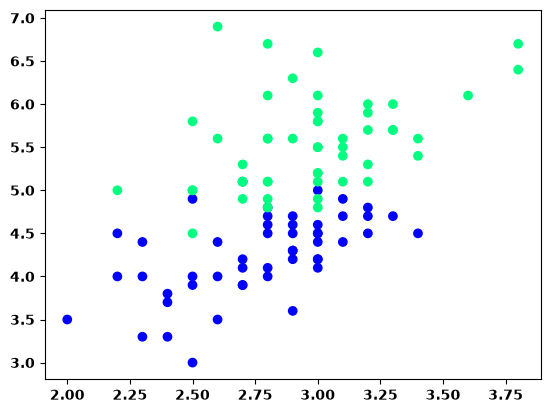

In [30]:
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['species'], cmap='winter')

In [31]:
# Taking only 10 rows for training 

df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [32]:
df_train

,sepal width (cm),petal length (cm),species
101,2.7,5.1,2
95,3.0,4.2,1
59,2.7,3.9,1
102,3.0,5.9,2
57,2.4,3.3,1
137,3.1,5.5,2
108,2.5,5.8,2
144,3.3,5.7,2
58,2.9,4.6,1
127,3.0,4.9,2


In [33]:
df_val

,sepal width (cm),petal length (cm),species
114,2.8,5.1,2
55,2.8,4.5,1
113,2.5,5.0,2
123,2.7,4.9,2
74,2.9,4.3,1


In [34]:
df_test

,sepal width (cm),petal length (cm),species
81,2.4,3.7,1
73,2.8,4.7,1
149,3.0,5.1,2
89,2.5,4.0,1
109,3.6,6.1,2


In [35]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

### Case 1 - Bagging

In [36]:
# Data for tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
108,2.5,5.8,2
101,2.7,5.1,2
102,3.0,5.9,2
59,2.7,3.9,1
95,3.0,4.2,1
57,2.4,3.3,1
101,2.7,5.1,2
137,3.1,5.5,2


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [38]:
dt_bag1 = DecisionTreeClassifier()

In [39]:
def evaluate (clf, X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


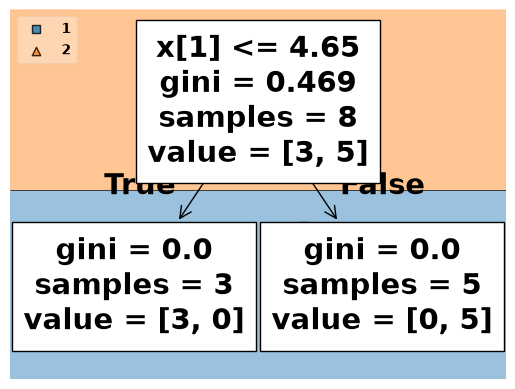

In [40]:
evaluate(dt_bag1, X,y)

In [41]:
# Data for tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
58,2.9,4.6,1
144,3.3,5.7,2
101,2.7,5.1,2
58,2.9,4.6,1
95,3.0,4.2,1
57,2.4,3.3,1
108,2.5,5.8,2
102,3.0,5.9,2


C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


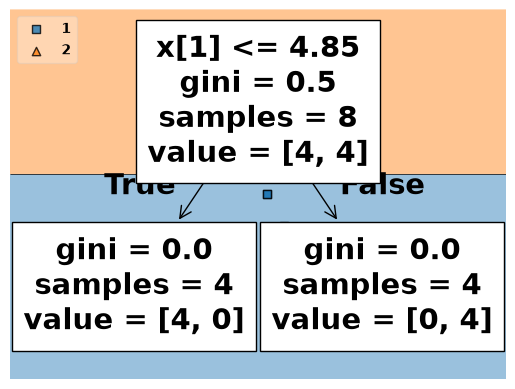

In [42]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, X,y)

In [43]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
137,3.1,5.5,2
127,3.0,4.9,2
102,3.0,5.9,2
137,3.1,5.5,2
108,2.5,5.8,2
58,2.9,4.6,1
59,2.7,3.9,1
58,2.9,4.6,1


C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


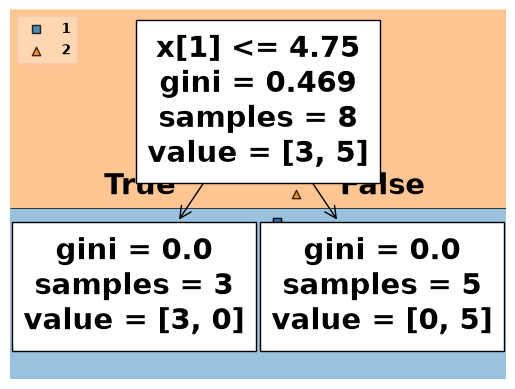

In [44]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, X,y)

### Prediction

In [55]:
df_test

,sepal width (cm),petal length (cm),species
81,2.4,3.7,1
73,2.8,4.7,1
149,3.0,5.1,2
89,2.5,4.0,1
109,3.6,6.1,2


In [58]:
import numpy as np

X_new = np.array([ 2.5, 4.0]).reshape(1, 2)

print('Predictor 1', dt_bag1.predict(X_new))
print('Predictor 2', dt_bag2.predict(X_new))
print('Predictor 3', dt_bag3.predict(X_new))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\praja\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Pasting

Pasting = random sampling of rows without replacement.

You select different subsets of the training examples (rows), but once a row is selected, it isn't selected again in that particular sample.

In [59]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),species
101,2.7,5.1,2
95,3.0,4.2,1
59,2.7,3.9,1
102,3.0,5.9,2
57,2.4,3.3,1
137,3.1,5.5,2
108,2.5,5.8,2
144,3.3,5.7,2
58,2.9,4.6,1
127,3.0,4.9,2


In [60]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
57,2.4,3.3,1
59,2.7,3.9,1
127,3.0,4.9,2
108,2.5,5.8,2
58,2.9,4.6,1
137,3.1,5.5,2
101,2.7,5.1,2
95,3.0,4.2,1


### Random Subspaces

Random Subspaces = random sampling of features (columns).

Instead of selecting different rows, we select different features/columns.

In [61]:
df1 = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df1["species"] = iris.target

df1 = df1.sample(10)


In [62]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
2,4.7,3.2,1.3,0.2,0
42,4.4,3.2,1.3,0.2,0
35,5.0,3.2,1.2,0.2,0
114,5.8,2.8,5.1,2.4,2
39,5.1,3.4,1.5,0.2,0
140,6.7,3.1,5.6,2.4,2
125,7.2,3.2,6.0,1.8,2
65,6.7,3.1,4.4,1.4,1
136,6.3,3.4,5.6,2.4,2
137,6.4,3.1,5.5,1.8,2


In [69]:
df1.sample(2, replace=True, axis=1)

,sepal length (cm),petal width (cm)
2,4.7,0.2
42,4.4,0.2
35,5.0,0.2
114,5.8,2.4
39,5.1,0.2
140,6.7,2.4
125,7.2,1.8
65,6.7,1.4
136,6.3,2.4
137,6.4,1.8


### Random Patches

Random Patches = random sampling of both rows AND columns.

So each model gets:
- a random subset of rows
- a random subset of features

In [71]:
df1.sample(8, replace=True).sample(2, replace=True, axis=1)

,sepal width (cm),species
125,3.2,2
42,3.2,0
137,3.1,2
140,3.1,2
39,3.4,0
114,2.8,2
39,3.4,0
42,3.2,0


> Pasting → Rows + Without replacement

---

> Random Subspaces → Columns/features

---

> Random Patches → Rows + Columns

---

### Quick comparison

| Method               | Rows     | Features    |
| -------------------- | -------- | ----------- |
| **Pasting**          | ✅ Random | ❌ All       |
| **Random Subspaces** | ❌ All    | ✅ Random    |
| **Random Patches**   | ✅ Random | ✅ Random    |
| **Bagging**          | ✅ Random | Usually all |

### 🧠 Easy way to remember

Think of a dataset as an Excel sheet:

```text
        COLUMNS → Features
       ↓
Rows   ┌───────────────┐
       │               │
       │    DATA       │
       │               │
       └───────────────┘
```

* **Pasting** → cut out some **rows**
* **Random Subspaces** → cut out some **columns**
* **Random Patches** → cut out some **rows + columns**
